In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tessrip import Rip
from tqdm import tqdm

In [2]:
import lightkurve as lk

In [3]:
lk.search_lightcurve

<function lightkurve.search.search_lightcurve(target, radius=None, exptime=None, cadence=None, mission=('Kepler', 'K2', 'TESS'), author=None, quarter=None, month=None, campaign=None, sector=None, limit=None)>

# Get TESS data

### tess rip 

In [21]:
rips = Rip(sector=7, camera=3, ccd=4)

In [22]:
rips.primary_hdu.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
NEXTEND =                    2 / number of standard extensions                  
EXTNAME = 'PRIMARY '           / name of extension                              
EXTVER  =                    1 / extension version number (not format version)  
SIMDATA =                    F / file is based on simulated data                
ORIGIN  = 'STScI/MAST'         / institution responsible for creating this file 
DATE    = '2021-08-25'         / file creation date.                            
TSTART  =    1491.627067695232 / observation start time in BTJD                 
TSTOP   =    1516.085668710438 / observation stop time in BTJD                  
DATE-OBS= '2019-01-08T03:01:49.465' / TSTART as UTC calendar date               
DATE-END= '2019-02-01T14:02:

In [23]:
rec = rips.last_hdulist[0].data

In [24]:
rec["NAXIS1"], rec["NAXIS2"]

(array([2136, 2136, 2136, ..., 2136, 2136, 2136], dtype='>i4'),
 array([2078, 2078, 2078, ..., 2078, 2078, 2078], dtype='>i4'))

In [25]:
rips.time

name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'

In [26]:
rips.cadence_number.array

array([   1,    2,    3, ..., 1171, 1172, 1173], dtype=int16)

In [27]:
rips.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 113.12187880084048  -51.91691819832046  
CRPIX : 1045.0  1001.0  
CD1_1 CD1_2  : 0.005627058768453578  0.001134953255849511  
CD2_1 CD2_2  : -0.00099947710335435  0.005595125550464286  
NAXIS : 2136.0  2078.0

In [28]:
rips.wcss[268]

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 113.1218997891522  -51.91696812318164  
CRPIX : 1045.0  1001.0  
CD1_1 CD1_2  : 0.005627055835877446  0.001134959797999  
CD2_1 CD2_2  : -0.0009994786625641  0.005595123679360293  
NAXIS : 2136  2078

In [ ]:
flx, flx_e = rips.get_flux(shape=(400, 500), corner=(0, 44))
flx.array.shape

In [18]:
rips.center, rips.corner

((1074.0, 1108.0), (1014, 1058))

In [19]:
flx

name = 'FLUX'; format = '12000E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(100, 120)'

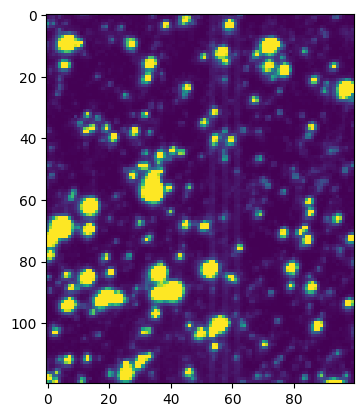

In [20]:
plt.imshow(flx.array[0], vmin=np.percentile(flx.array[0], 5), vmax=np.percentile(flx.array[0], 95))
plt.show()

In [24]:
tpf = rips.get_tpf(shape=(64, 64)).copy()

In [18]:
tpf.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      57   ()      
  1  PIXELS        1 BinTableHDU     32   1245R x 6C   ['D', 'E', 'I', 'J', '4096E', '4096E']   
  2  APERTURE      1 ImageHDU        85   (64, 64)   float64   


In [23]:
tpf[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                32786 / length of dimension 1                          
NAXIS2  =                 1245 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    6 / number of table fields                         
TTYPE1  = 'TIME    '                                                            
TFORM1  = 'D       '                                                            
TUNIT1  = 'BJD - 2457000, days'                                                 
TDISP1  = 'D14.7   '                                                            
TTYPE2  = 'TIMECORR'        

In [21]:
delete_kwds = ["NAXIS1", "NAXIS2", "NAXIS3", "NAXIS4"]

for kwd in delete_kwds:
        if kwd in tpf[0].header:
            del tpf[0].header[kwd]

In [22]:
tpf.writeto("./data/tessrip_tpf_test.fits", overwrite=True)

## tess rip to get uniform pixel grid from FFI

In [16]:
r_min = 0 + 1
r_max = 2048 + 1
c_min = 45 + 1
c_max = 2093 + 1

In [17]:
2048 ** 2

4194304

In [18]:
row, col = np.mgrid[r_min : r_max : 16, c_min : c_max : 16]
print(row.shape, col.shape)

coordinates = np.array([[i, j] for i, j in zip(row.ravel(), col.ravel())])
print(coordinates.shape)
print((coordinates.shape[0])/(2048 ** 2) * 100)


(128, 128) (128, 128)
(16384, 2)
0.390625


In [19]:
flux, flux_err = [], []

for aux in tqdm(np.array_split(coordinates, 100), 
                total=len(np.array_split(coordinates, 100))):
    flx, flx_e = rips.get_pixel_timeseries(aux)
    flux.append(flx)
    flux_err.append(flx_e)
flux = np.concatenate(flux, axis=1)
flux_err = np.concatenate(flux_err, axis=1)

100%|███████████████████████████████████████████████████████████████████████████████| 100/100 [05:09<00:00,  3.09s/it]


In [20]:
from astropy.stats import sigma_clip

In [21]:
mask = ~sigma_clip(np.log10(flux.mean(axis=0)), sigma_lower=10, sigma_upper=5, masked=True).mask
mask.sum()

15834

In [22]:
cad = 610
cad

610

In [23]:
flux[cad, mask]

array([167.68914795, 166.27944946, 165.13572693, ..., 174.4078064 ,
       161.68281555, 158.7167511 ])

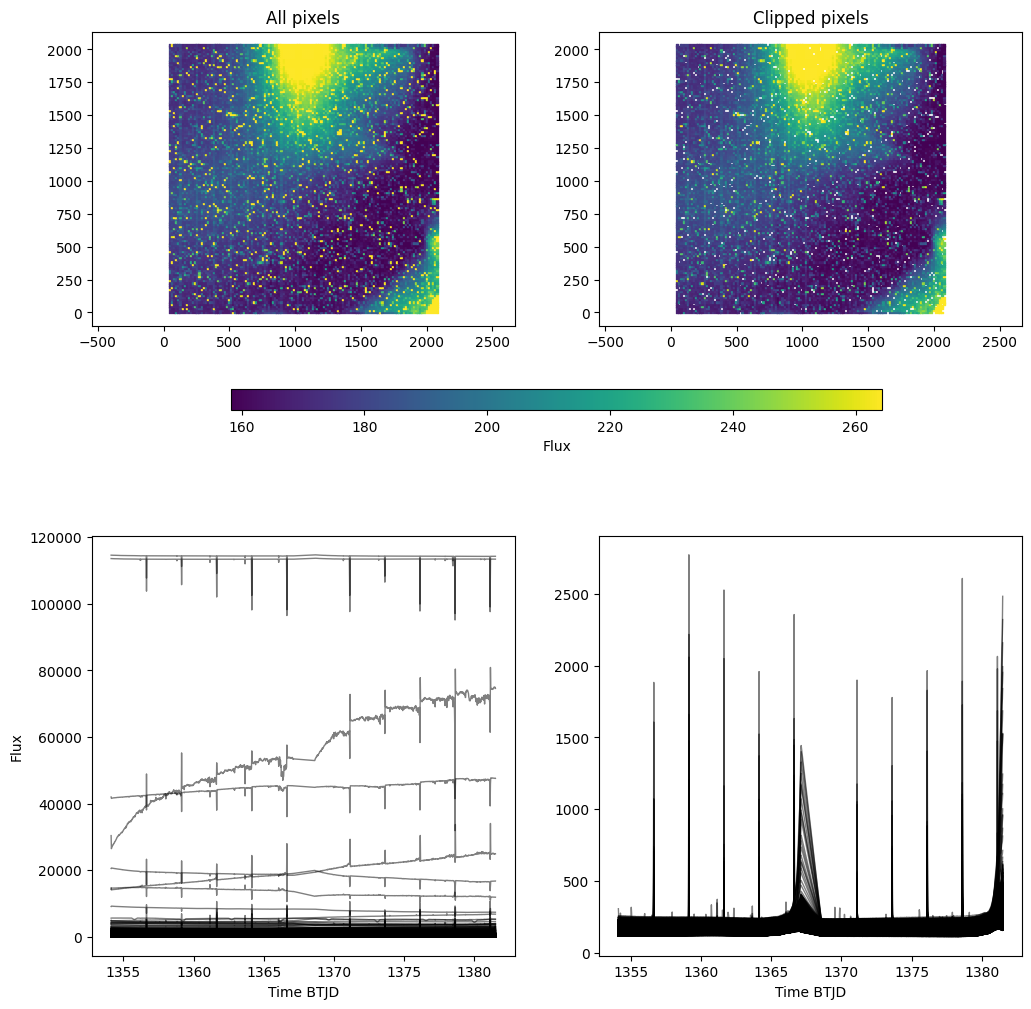

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))

vmin, vmax = np.percentile(flux[cad, mask], [3, 97])

bar1 = ax[0, 0].scatter(coordinates[:, 1], 
                  coordinates[:, 0], 
                  c=flux[cad, :], 
                  marker="s",
                  s=1,
                  vmin=vmin, vmax=vmax)

bar2 = ax[0, 1].scatter(coordinates[mask, 1], 
                  coordinates[mask, 0], 
                  c=flux[cad, mask], 
                  marker="s",
                  s=1,
                  vmin=vmin, vmax=vmax)
cbar = plt.colorbar(bar2, ax=ax[0], orientation="horizontal", shrink=0.7, label="Flux", aspect=30)
# cbar.
ax[0, 0].axis('equal')
ax[0, 1].axis('equal')

for k in range(len(coordinates)):
    ax[1, 0].plot(rips.time.array, flux[:, k], c="k", alpha=.5, lw=1, rasterized=True)
    if mask[k]:
        ax[1, 1].plot(rips.time.array, flux[:, k], c="k", alpha=.5, lw=1, rasterized=True)
ax[1, 0].set_xlabel("Time BTJD")
ax[1, 1].set_xlabel("Time BTJD")
ax[1, 0].set_ylabel("Flux")
ax[0, 0].set_title("All pixels")
ax[0, 1].set_title("Clipped pixels")
plt.show()

# GP 2D for one cadence

In [62]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import *

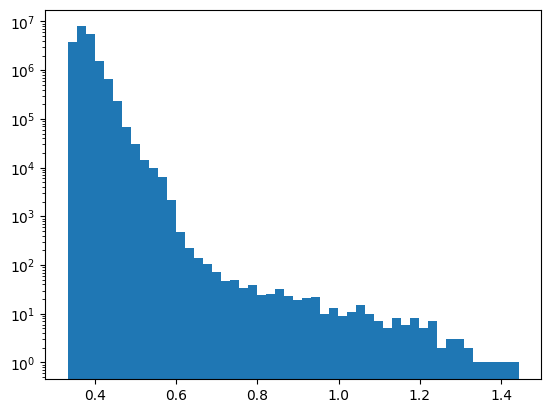

In [63]:
plt.hist(flux_err[:, mask].ravel(), bins=50, log=True)
plt.show()

In [64]:
coordinates.shape, mask.shape

((16384, 2), (16384,))

In [77]:
mask_clip = mask
mask_corner = (coordinates[:, 0] > 0) & (coordinates[:, 1] < 5000)

In [78]:
flux_mean = flux[:, mask_clip].mean(axis=1)
flux_std = flux[:, mask_clip].std(axis=1)
print(flux_mean, flux_std)
flux_whitten = (flux - flux_mean[:, None]) / flux_std[:, None]
flux_mean.shape, flux.shape, flux_whitten.shape

[142.56048833 142.54121619 142.51022465 ... 226.48070328 225.67496217
 225.5545523 ] [16.20158937 16.19962454 16.18221592 ... 75.81391144 77.44472808
 80.54710249]


((1245,), (1245, 16384), (1245, 16384))

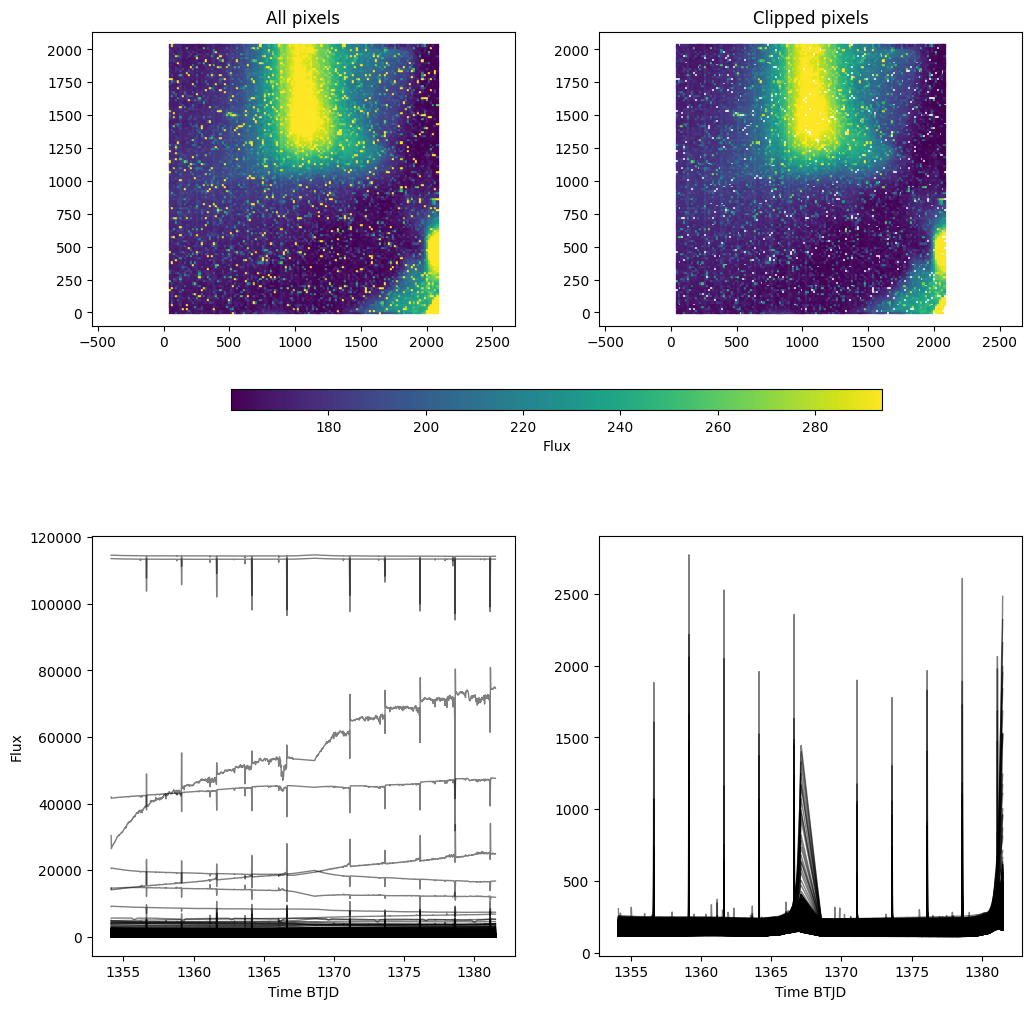

In [79]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))

vmin, vmax = np.percentile(flux[cad, mask_clip & mask_corner], [3, 97])

bar1 = ax[0, 0].scatter(coordinates[mask_corner, 1], 
                  coordinates[mask_corner, 0], 
                  c=flux[cad, mask_corner], 
                  marker="s",
                  s=1,
                  vmin=vmin, vmax=vmax)

bar2 = ax[0, 1].scatter(coordinates[mask_clip & mask_corner, 1], 
                  coordinates[mask_clip & mask_corner, 0], 
                  c=flux[cad, mask_clip & mask_corner], 
                  marker="s",
                  s=1,
                  vmin=vmin, vmax=vmax)
cbar = plt.colorbar(bar2, ax=ax[0], orientation="horizontal", shrink=0.7, label="Flux", aspect=30)
# cbar.
ax[0, 0].axis('equal')
ax[0, 1].axis('equal')

for k, val in enumerate(mask_corner):
    if val:
        ax[1, 0].plot(rips.time.array, flux[:, k], c="k", alpha=.5, lw=1, rasterized=True)
        if mask_clip[k]:
            ax[1, 1].plot(rips.time.array, flux[:, k], c="k", alpha=.5, lw=1, rasterized=True)
ax[1, 0].set_xlabel("Time BTJD")
ax[1, 1].set_xlabel("Time BTJD")
ax[1, 0].set_ylabel("Flux")
ax[0, 0].set_title("All pixels")
ax[0, 1].set_title("Clipped pixels")
plt.show()

In [80]:
mask_cc = mask_clip & mask_corner

coordinates[mask_cc].shape, flux_whitten[cad, mask_cc].shape

((15834, 2), (15834,))

In [81]:
kernel = (
    # ConstantKernel(
    # constant_value=np.sqrt(flux[cad, mask_cc].mean()), 
    # constant_value_bounds=np.percentile(flux[cad, mask_cc].mean(), [5, 95])) 
    1
          * Matern(
              length_scale=64, 
              length_scale_bounds=(2, 128.0), nu=1.5)
         )
kernel

1**2 * Matern(length_scale=64, nu=1.5)

In [82]:
GP = GaussianProcessRegressor(kernel=kernel, 
                              alpha=flux_err[cad, mask_cc].mean() ** 2, 
                              random_state=0, 
                              normalize_y=True,
                             )
GP.fit(coordinates[mask_cc], flux[cad, mask_cc])

/Users/jorgemarpa/.pyenv/versions/tess-test/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:434: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 128.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=0.1774042002899893,
                         kernel=1**2 * Matern(length_scale=64, nu=1.5),
                         normalize_y=True, random_state=0)

In [83]:
GP.get_params()

{'alpha': 0.1774042002899893,
 'copy_X_train': True,
 'kernel__k1': 1**2,
 'kernel__k2': Matern(length_scale=64, nu=1.5),
 'kernel__k1__constant_value': 1,
 'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
 'kernel__k2__length_scale': 64,
 'kernel__k2__length_scale_bounds': (2, 128.0),
 'kernel__k2__nu': 1.5,
 'kernel': 1**2 * Matern(length_scale=64, nu=1.5),
 'n_restarts_optimizer': 0,
 'n_targets': None,
 'normalize_y': True,
 'optimizer': 'fmin_l_bfgs_b',
 'random_state': 0}

In [84]:
flux_eval, flux_std_eval = GP.predict(coordinates[mask_corner], return_std=True)

In [85]:
coordinates[mask_corner].shape

(16384, 2)

In [86]:
row_d, col_d = np.mgrid[
            coordinates[mask_corner, 0].min() : coordinates[mask_corner, 0].max(), 
            coordinates[mask_corner, 1].min() : coordinates[mask_corner, 1].max()]

coordinates_d = np.array([[i, j] for i, j in zip(row_d.ravel(), col_d.ravel())])
row_d.shape, col_d.shape, coordinates_d.shape

((2032, 2032), (2032, 2032), (4129024, 2))

In [88]:
# flux_eval_d, flux_std_eval_d = GP.predict(coordinates_d, return_std=True)
flux_eval_d, flux_std_eval_d = [], []

for aux in tqdm(np.array_split(coordinates_d, 400), 
                total=len(np.array_split(coordinates_d, 400))):
    eval, eval_e = GP.predict(aux, return_std=True)
    flux_eval_d.append(eval)
    flux_std_eval_d.append(eval_e)
flux_eval_d = np.concatenate(flux_eval_d, axis=0)
flux_std_eval_d = np.concatenate(flux_std_eval_d, axis=0)
flux_eval_d = flux_eval_d.reshape(row_d.shape)
flux_std_eval_d = flux_std_eval_d.reshape(row_d.shape)

100%|█████████████████████████████████████████████████████████████████████████████| 400/400 [2:47:09<00:00, 25.07s/it]


In [121]:
# plt.style.use('seaborn-notebook')
plt.rc('axes', labelsize=13) 
plt.rc('axes', titlesize=14)
plt.rc('legend',fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

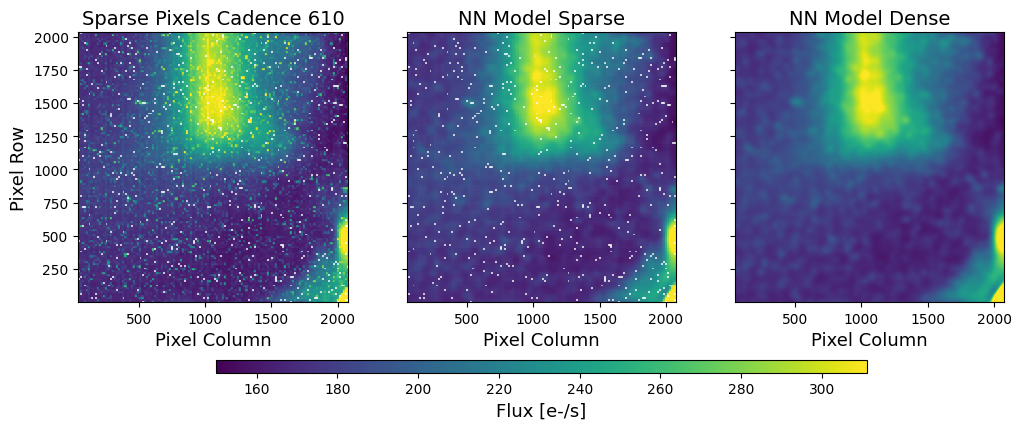

In [123]:
vlo, lo, mid, hi, vhi = np.nanpercentile(flux[cad, mask_clip], [0.01, 1, 50, 95, 99])

fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)

bar = ax[0].scatter(coordinates[mask_cc, 1], 
                  coordinates[mask_cc, 0], 
                  c=flux[cad, mask_cc], 
                  marker="s",
                  s=0.9,
                  vmin=vlo, vmax=vhi,
                   rasterized=True)
# fig.colorbar(bar, ax=ax[0], orientation="horizontal", shrink=0.7)

bar = ax[1].scatter(coordinates[mask_cc, 1], 
                  coordinates[mask_cc, 0], 
                  c=flux_eval[mask_cc], 
                  marker="s",
                  s=0.9,
                  vmin=vlo, vmax=vhi,
                   rasterized=True)
# fig.colorbar(bar, ax=ax[1], orientation="horizontal", shrink=0.7)

bar = ax[2].pcolormesh(col_d, 
                       row_d, 
                       flux_eval_d.reshape(row_d.shape),
                       vmin=vlo, vmax=vhi,
                      rasterized=True)
fig.colorbar(bar, ax=ax, orientation="horizontal", shrink=0.7, label="Flux [e-/s]", aspect=50)

ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')
ax[2].set_aspect('equal', adjustable='box')

ax[0].set_title(f"Sparse Pixels Cadence {610}")
ax[1].set_title("NN Model Sparse")
ax[2].set_title("NN Model Dense")

ax[0].set_xlabel("Pixel Column")
ax[1].set_xlabel("Pixel Column")
ax[2].set_xlabel("Pixel Column")
ax[0].set_ylabel("Pixel Row")

ax[2].set_xlim(col_d.min(), col_d.max())
ax[2].set_ylim(row_d.min(), row_d.max())

plt.savefig(f"figures/tess_ffi_sector{rips.sector:04}-{rips.camera}-{rips.ccd}_cad{610:04}_NN_prototype.pdf", bbox_inches="tight")

plt.show()

In [110]:
rips.sector

2

In [103]:
col_d.min(), row_d.min()

(46, 1)

## GP for 3D all cadences

In [40]:
import astropy.units as u

In [41]:
rips.time.array.shape, flux_whitten.shape

((1288,), (1288, 16384))

In [42]:
mask_corner2 = ((coordinates[:, 0] > 1000) & 
               (coordinates[:, 0] < 1500) & 
               (coordinates[:, 1] > 500) & 
               (coordinates[:, 1] < 1000))
print(mask_corner2.sum())
mask_cc2 = mask_clip & mask_corner2

961


In [49]:
# we run a median window in time to reduce the size of time dim
window = np.max(np.where(rips.time.array - rips.time.array[0] < (8 * u.hour).to("d").value))
step = window // 2

cad_min, cad_max = 520, 620

print(f"Step is {step} window is {window}")

time_lowres  = pd.Series(rips.time.array[cad_min : cad_max]).rolling(
    window=window, step=step, min_periods=1).median().values
flux_lowres = pd.DataFrame(flux[cad_min : cad_max]).rolling(
    window=window, step=step, min_periods=1, axis=0).median().values
flux_err_lowres = pd.DataFrame(flux_err[cad_min : cad_max]).rolling(
    window=window, step=step, min_periods=1, axis=0).median().values

time_lowres.shape, flux_lowres.shape

Step is 7 window is 15


((15,), (15, 16384))

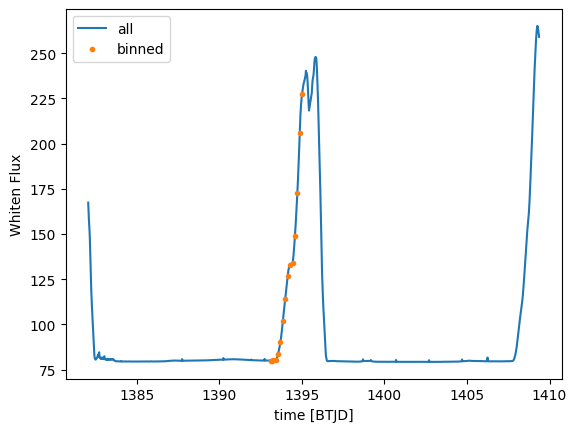

In [50]:
plt.plot(rips.time.array, np.median(flux, axis=1), label="all")
plt.plot(time_lowres, np.median(flux_lowres, axis=1), ".", label="binned")
plt.xlabel("time [BTJD]")
plt.ylabel("Whiten Flux")
plt.legend()
plt.show()

In [51]:
flux[:, mask_cc2].shape, flux_lowres[:, mask_cc2].shape

((1288, 922), (15, 922))

In [52]:
np.multiply(*flux_lowres[:, mask_cc2].shape)

13830

In [53]:
print(f"Using {np.multiply(*flux_lowres[:, mask_cc2].shape) / np.multiply(*flux[cad_min: cad_max, mask_cc2].shape) * 100:f} % of all data to fit GP")


Using 15.000000 % of all data to fit GP


In [54]:
kernel_3d = (
    # ConstantKernel(
    # constant_value=np.sqrt(flux[cad, mask_cc].mean()), 
    # constant_value_bounds=np.percentile(flux[cad, mask_cc].mean(), [5, 95])) 
    1
    * Matern(
        length_scale=64, 
        length_scale_bounds=(2, 128.0), nu=1.5)
        )
kernel

1**2 * Matern(length_scale=64, nu=1.5)

In [65]:
coord_3d = np.vstack([[[x[0], x[1], t] for t in time_lowres] for x in coordinates[mask_cc2]])
coord_3d.shape

(13830, 3)

In [56]:
coord_3d.shape, flux_lowres[:, mask_cc2].T.ravel().shape

((13830, 3), (13830,))

In [57]:
GP_3d = GaussianProcessRegressor(
    kernel=kernel_3d, 
    alpha=flux_err_lowres[:, mask_cc2].mean() ** 2, 
    random_state=1, 
    normalize_y=True,
)
GP_3d

GaussianProcessRegressor(alpha=0.11904223770815345,
                         kernel=1**2 * Matern(length_scale=64, nu=1.5),
                         normalize_y=True, random_state=1)

In [75]:
flux_lowres[:, mask_cc2].shape

(15, 922)

In [58]:
GP_3d.fit(coord_3d, flux_lowres[:, mask_cc2].T.ravel())

GaussianProcessRegressor(alpha=0.11904223770815345,
                         kernel=1**2 * Matern(length_scale=64, nu=1.5),
                         normalize_y=True, random_state=1)

In [60]:
GP_3d.get_params()

{'alpha': 0.11904223770815345,
 'copy_X_train': True,
 'kernel__k1': 1**2,
 'kernel__k2': Matern(length_scale=64, nu=1.5),
 'kernel__k1__constant_value': 1,
 'kernel__k1__constant_value_bounds': (1e-05, 100000.0),
 'kernel__k2__length_scale': 64,
 'kernel__k2__length_scale_bounds': (2, 128.0),
 'kernel__k2__nu': 1.5,
 'kernel': 1**2 * Matern(length_scale=64, nu=1.5),
 'n_restarts_optimizer': 0,
 'n_targets': None,
 'normalize_y': True,
 'optimizer': 'fmin_l_bfgs_b',
 'random_state': 1}

In [61]:
GP_3d.score(coord_3d, flux_lowres[:, mask_cc2].T.ravel())

0.9829781759620271

In [66]:
coord_c2_3d = np.vstack([[[x[0], x[1], t] for t in time_lowres] for x in coordinates[mask_corner2]])
coord_c2_3d.shape

(14415, 3)

In [73]:
flux_3dsparse_eval, flux_std_3dsparse_eval = GP_3d.predict(coord_c2_3d, 
                                                        return_std=True)

In [79]:
flux_3dsparse_eval = flux_3dsparse_eval.reshape((time_lowres.shape[0],
                                                 coordinates[mask_corner2].shape[0]))
flux_std_3dsparse_eval = flux_std_3dsparse_eval.reshape((time_lowres.shape[0],
                                                 coordinates[mask_corner2].shape[0]))

In [80]:
flux_3dsparse_eval.shape

(15, 961)

In [87]:
row_cc2_d2d, col_cc2_d2d = np.mgrid[
            coordinates[mask_corner2, 0].min() : coordinates[mask_corner2, 0].max(), 
            coordinates[mask_corner2, 1].min() : coordinates[mask_corner2, 1].max()]

coord_cc2_d2d = np.array([[i, j] for i, j in zip(row_cc2_d2d.ravel(), col_cc2_d2d.ravel())])
row_cc2_d2d.shape, col_cc2_d2d.shape, coord_cc2_d2d.shape

((480, 480), (480, 480), (230400, 2))

In [110]:
coord_cc2_d3d

array([[1009.        ,  510.        , 1395.18053741],
       [1009.        ,  511.        , 1395.18053741],
       [1009.        ,  512.        , 1395.18053741],
       ...,
       [1488.        ,  987.        , 1395.18053741],
       [1488.        ,  988.        , 1395.18053741],
       [1488.        ,  989.        , 1395.18053741]])

In [128]:
flux_d3d_eval, flux_std_d3d_eval = [], []

for k, t in tqdm(enumerate(rips.time.array[cad_min : cad_min + 10]), 
                 total=10):
    flux_cad_aux, flux_std_cad_aux = [], []

    coord_cc2_d3d = np.append(coord_cc2_d2d, 
                              np.array([t] * coord_cc2_d2d.shape[0])[:, None], 
                              axis=1)

    for aux in np.array_split(coord_cc2_d3d, 100): 
                    # total=len(np.array_split(coord_cc2_d3d, 100)), 
                    # leave=False):
        eval, eval_e = GP_3d.predict(aux, return_std=True)
        flux_cad_aux.append(eval)
        flux_std_cad_aux.append(eval_e)
        
    flux_cad_aux = np.concatenate(flux_cad_aux, axis=0)
    flux_std_cad_aux = np.concatenate(flux_std_cad_aux, axis=0)
    flux_d3d_eval.append(flux_cad_aux.reshape(row_cc2_d2d.shape))
    flux_std_d3d_eval.append(flux_std_cad_aux.reshape(row_cc2_d2d.shape))

flux_d3d_eval = np.array(flux_d3d_eval)
flux_std_d3d_eval = np.array(flux_std_d3d_eval)

100%|██████████████████████████████████████████████████████████████████████████████| 10/10 [1:31:45<00:00, 550.53s/it]


In [129]:
flux_d3d_eval.shape

(10, 480, 480)

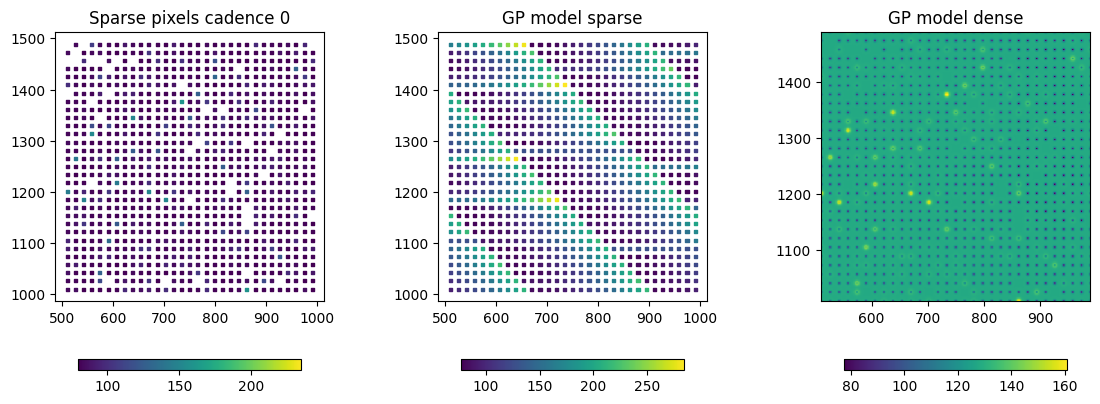

In [138]:
cad_plot = 5
vmin, vmax = np.percentile(flux[cad_min : cad_max, mask_clip & mask_corner2], [3, 97])

fig, ax = plt.subplots(1,3, figsize=(14, 5))

bar = ax[0].scatter(coordinates[mask_cc2, 1], 
                  coordinates[mask_cc2, 0], 
                  c=flux[cad_min + cad_plot, mask_cc2], 
                  marker="s",
                  s=5,
                  vmin=vmin, vmax=vmax)
fig.colorbar(bar, ax=ax[0], orientation="horizontal", shrink=0.7)

bar = ax[1].scatter(coordinates[mask_corner2, 1], 
                  coordinates[mask_corner2, 0], 
                  c=flux_3dsparse_eval[cad_plot], 
                  marker="s",
                  s=5,)
                  # vmin=vmin, vmax=vmax)
fig.colorbar(bar, ax=ax[1], orientation="horizontal", shrink=0.7)

bar = ax[2].pcolormesh(col_cc2_d2d, 
                       row_cc2_d2d, 
                       flux_d3d_eval[cad_plot])
                  # vmin=vmin, vmax=vmax)
fig.colorbar(bar, ax=ax[2], orientation="horizontal", shrink=0.7)

ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')
ax[2].set_aspect('equal', adjustable='box')

ax[0].set_title(f"Sparse pixels cadence {0}")
ax[1].set_title("GP model sparse")
ax[2].set_title("GP model dense")

plt.show()

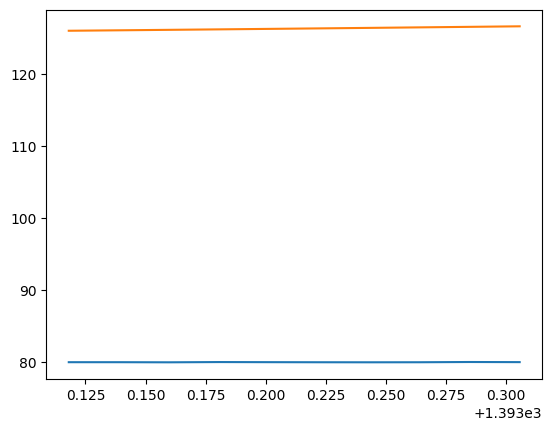

In [151]:
plt.plot(rips.time.array[cad_min : cad_min + 10], np.median(flux, axis=1)[cad_min : cad_min + 10])
plt.plot(rips.time.array[cad_min : cad_min + 10], np.mean(flux_d3d_eval.reshape((10, -1)), axis=1))


# PCA

In [27]:
from fbpca import pca


In [28]:
col_s, row_s = coordinates[mask, 1], coordinates[mask, 0]

row_d, col_d = np.mgrid[r_min : r_max, c_min : c_max]
row_d.shape

(2048, 2048)

In [29]:
# Polynomial design matrix...
Xs = np.vstack([row_s.ravel()**idx * col_s.ravel()**jdx for idx in range(3) for jdx in range(3)]).T
Xd = np.vstack([row_d.ravel()**idx * col_d.ravel()**jdx for idx in range(3) for jdx in range(3)]).T

Xs.shape, Xd.shape

((15091, 9), (4194304, 9))

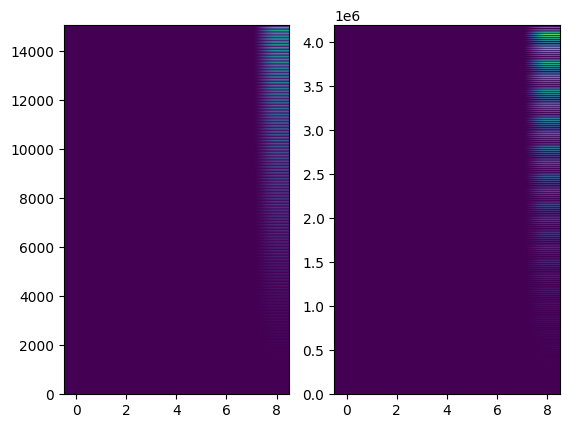

In [30]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(Xs, aspect="auto", origin="lower")
ax[1].imshow(Xd, aspect="auto", origin="lower")
plt.show()

In [31]:
np.median(flux, axis=0).shape

(16384,)

In [32]:
med = np.median(flux, axis=0)
flux_med = flux - med

# Get the PCA components for the background data, up to 10
U, s, Vs = pca(flux_med[:, mask], 4)
# Use a polynomial model to in-fill the "V" component wherever there are sources!!
Vd = (Xd.dot(np.linalg.solve(Xs.T.dot(Xs), Xs.T.dot(Vs.T))).T)

In [33]:
U.shape, s.shape, Vs.shape, Vd.shape

((1245, 4), (4,), (4, 15091), (4, 4194304))

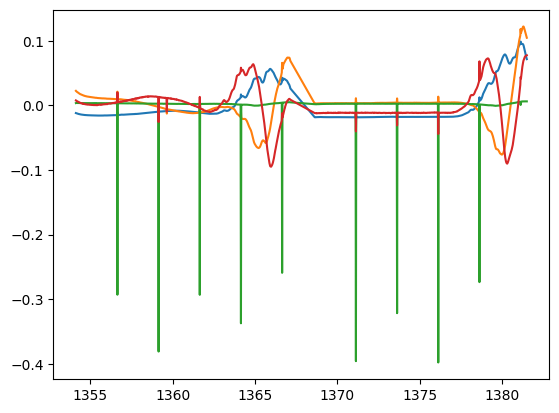

In [34]:
plt.plot(rips.time.array, U)
plt.show()

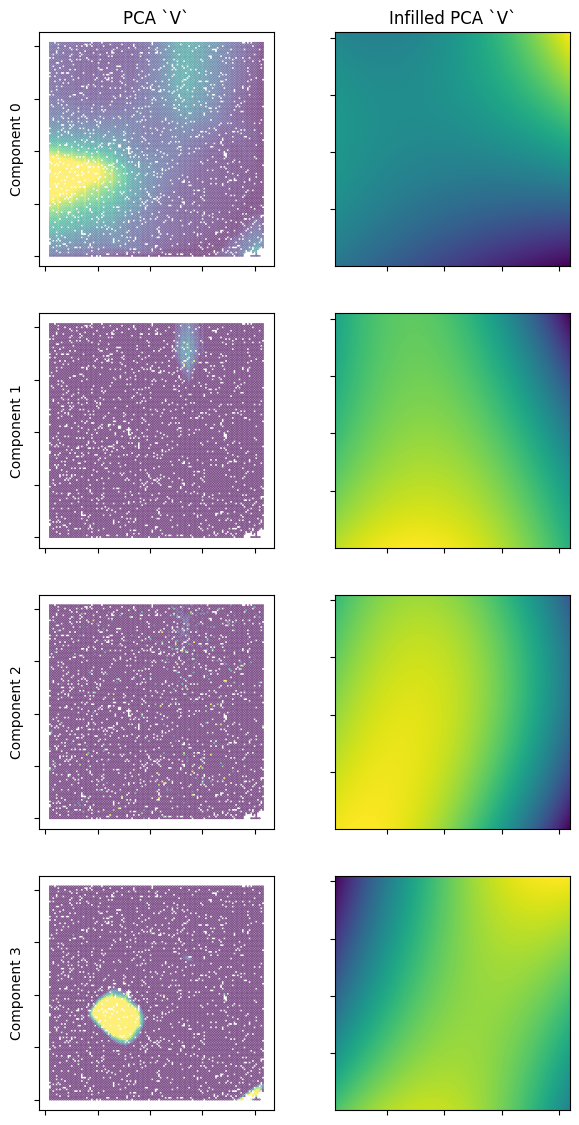

In [35]:
fig, ax = plt.subplots(Vs.shape[0], 2, figsize=(7, 3.5*Vs.shape[0]))
for vdx in range(Vs.shape[0]):

    sparse_ima = Vs[vdx]
    dense_ima = Vd[vdx].reshape(row_d.shape)

    vmin, vmax = np.sort(np.abs(np.nanpercentile(sparse_ima, (3, 97))))
    ax[vdx, 0].scatter(coordinates[mask, 1], 
                       coordinates[mask, 0], 
                       c=sparse_ima, 
                       s=.1,
                       vmin=vmin, 
                       vmax=vmax)
    ax[vdx, 1].pcolormesh(col_d, row_d, dense_ima, )

    ax[vdx, 0].set_aspect('equal', adjustable='box')
    ax[vdx, 1].set_aspect('equal', adjustable='box')

    if vdx == 0:
        ax[vdx, 0].set(title=f'PCA `V`')
        ax[vdx, 1].set(title=f'Infilled PCA `V`')
    ax[vdx, 0].set(ylabel=f'Component {vdx}', xticklabels=[], yticklabels=[])
    ax[vdx, 1].set(xticklabels=[], yticklabels=[])
plt.show()

In [ ]:
# Now my PCA model can be evaluated everywhere!
bkg_model = U.dot(np.diag(s)).dot(Vd).reshape([flux.shape[0], row_d.shape[0], row_d.shape[1]])

# Correct for offsets, bc TESS scattered light is an additive background
bkg_model -= np.percentile(bkg_model, 1)
# bkg_model += np.median((tpf - bkg_model - med).flux.mean(axis=0).value[~sources])

In [ ]:
from ipywidgets import *

In [64]:
%matplotlib notebook

In [66]:
idx = 0
vmin, vmax = np.percentile(flux_med[idx, mask], [3, 97])
fig, ax = plt.subplots(1,2, figsize=(12,7))
cbar1 = ax[0].scatter(col_s, 
                      row_s, 
                      c=flux_med[idx, mask],
                      marker="s",
                      s=0.5,
                      vmin=vmin, vmax=vmax)
fig.colorbar(cbar1, ax=ax[0], orientation="horizontal", shrink=.5)
cbar2 = ax[1].pcolormesh(col_d, row_d, bkg_model[idx], )
fig.colorbar(cbar2, ax=ax[1], orientation="horizontal", shrink=.5)
ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')

def update(idx=0):
    vmin, vmax = np.percentile(flux_med[idx, mask], [3, 97])
    cbar1 = ax[0].scatter(col_s, 
                        row_s, 
                        c=flux_med[idx, mask],
                        marker="s",
                        s=0.5,
                        vmin=vmin, vmax=vmax)
    fig.colorbar(cbar1, ax=ax[0], orientation="horizontal", shrink=.5)
    cbar2 = ax[1].pcolormesh(col_d, row_d, bkg_model[idx], )
    fig.colorbar(cbar2, ax=ax[1], orientation="horizontal", shrink=.5)
    ax[0].set_aspect('equal', adjustable='box')
    ax[1].set_aspect('equal', adjustable='box')

interact(update, idx=(0, len(flux), 1));

<IPython.core.display.Javascript object>

interactive(children=(IntSlider(value=0, description='idx', max=1245), Output()), _dom_classes=('widget-intera…

In [ ]:
# Correct for offsets, bc TESS scattered light is an additive background
bkg_model -= np.percentile(bkg_model, 1)
bkg_model += np.median((tpf - bkg_model - med).flux.mean(axis=0).value[~sources])